In [1]:
import pickle

import matplotlib.pyplot as plt
import numpy as np

from rgfn import ReactionDataFactory
from rgfn.gfns.reaction_gfn.proxies.path_cost_proxy import PathCostProxy
from pathlib import Path
from notebooks.utils.training_results import TrainingResults, TrainingResultsList

from collections import defaultdict

model_names = ['rgfn_is_decomposable', 'rgfn_cost_biasing']
model_map = {
    'rgfn_is_decomposable': 'SCENT (w/o C)',
    'rgfn_cost_biasing': 'SCENT (C)',
    'synflownet': 'SynFlowNet'
}
template_map = {
    'rgfn_new_filtered': 'SMALL',
    'synflow_64': 'MEDIUM'
}
metrics_map = {
    'last_n_paths_lengths': 'a) average paths length',
    'last_n_reaction_yield': 'd) average reaction yield',
    'last_n_price_of_fragments_in_path': 'b) average price of used fragments',
    'last_n_unique_fragments': 'c) average number of unique fragments'
}
y_axis_map = {
    'last_n_paths_lengths': 'path length',
    'last_n_reaction_yield': 'reaction yield',
    'last_n_price_of_fragments_in_path': 'price',
    'last_n_unique_fragments': 'unique fragments'
}

template_name = 'synflow_64'
data_dir = Path('../../data')
if template_name == 'synflow_64':
    cache_path = Path(f'cache/cost_analysis.pt')
else:
    cache_path = Path(f'cache/cost_analysis_{template_name}.pt')

load_from_cache = True

def get_path_cost_proxy(templates_name: str) -> PathCostProxy:
    if 'synflow' in templates_name:
        k = int(templates_name.split('_')[-1])
        return PathCostProxy(
            data_factory=ReactionDataFactory(
                reaction_path=data_dir / f'synflow/templates.txt',
                fragment_path=data_dir / f'synflow/fragment_{k}k.txt',
                cost_path=data_dir / f'synflow/fragment_{k}k_to_real_cost.json',
            ),
            yield_value=0.75
        )
    elif templates_name == 'rgfn_new_filtered':
        return PathCostProxy(data_factory=ReactionDataFactory(
            reaction_path=data_dir / 'rgfn_new_filtered/templates.txt',
            fragment_path=data_dir / 'rgfn_new_filtered/fragments.txt',
            cost_path=data_dir / f'rgfn_new_filtered/fragment_to_real_cost.json',
            yield_path=data_dir / 'rgfn_new_filtered/templates_yields.csv',
        ))
    else:
        raise ValueError(f"Unknown templates_name: {templates_name}")


path_cost_proxy = get_path_cost_proxy(template_name)


/Users/piotrgainski/miniconda3/envs/rgfn/lib/python3.11/site-packages/torch_geometric/typing.py:54: UserWarning: An issue occurred while importing 'pyg-lib'. Disabling its usage. Stacktrace: dlopen(/Users/piotrgainski/miniconda3/envs/rgfn/lib/python3.11/site-packages/libpyg.so, 0x0006): Library not loaded: /Library/Frameworks/Python.framework/Versions/3.11/Python
  Referenced from: <75FFC412-93B5-322B-8E6D-268DA3498CF4> /Users/piotrgainski/miniconda3/envs/rgfn/lib/python3.11/site-packages/libpyg.so
  Reason: tried: '/Library/Frameworks/Python.framework/Versions/3.11/Python' (no such file), '/System/Volumes/Preboot/Cryptexes/OS/Library/Frameworks/Python.framework/Versions/3.11/Python' (no such file), '/Library/Frameworks/Python.framework/Versions/3.11/Python' (no such file)
  warnings.warn(f"An issue occurred while importing 'pyg-lib'. "
/Users/piotrgainski/miniconda3/envs/rgfn/lib/python3.11/site-packages/torch_geometric/typing.py:110: UserWarning: An issue occurred while importing 'to

Using 64000 fragments, 105 reactions, and 197 anchored reactions
Cost mean and variance (165.35871676652314, 141.97387057883336)
Cost max 999.2437529950079


In [2]:
from tqdm import tqdm
from typing import List


def extract_fragments(result: TrainingResults):
    fragments_list_list = []
    for path in result.paths:
        fragments_list = []
        for item in path:
            if isinstance(item, (list, tuple)):
                fragments = [f for f in item[1:] if isinstance(f, str)]
                fragments_list.extend(fragments)
        fragments_list_list.append(fragments_list)
    return fragments_list_list


def extract_paths_lengts(result: TrainingResults):
    return [len([item for item in path if isinstance(item, (list, tuple))]) for path in result.paths]


def get_last_n_mean(items: List[int], n: int) -> List[int]:
    values = np.array(items)
    cumsum = np.cumsum(values)
    return (cumsum[n:] - cumsum[:-n]) / n


def extract_templates(result: TrainingResults):
    templates_list_list = []
    for path in result.paths:
        templates_list = []
        for item in path:
            if isinstance(item, (list, tuple)):
                templates_list.append(item[0])
        templates_list_list.append(templates_list)
    return templates_list_list


def get_last_n_unique_fragments(result: TrainingResults, n: int):
    current_fragments_list_list = []
    current_fragments_counter = {}
    result_list = []
    for fragments_list in result.fragments_list_list:
        if len(current_fragments_list_list) > n:
            last_fragment_list = current_fragments_list_list.pop(0)
            for fragment in last_fragment_list:
                current_fragments_counter[fragment] -= 1
                if current_fragments_counter[fragment] == 0:
                    del current_fragments_counter[fragment]
        current_fragments_list_list.append(fragments_list)
        for fragment in fragments_list:
            current_fragments_counter[fragment] = current_fragments_counter.get(fragment, 0) + 1
        result_list.append(len(current_fragments_counter))
    return result_list


def get_last_n_unique_templates(result: TrainingResults, n: int):
    current_templates_list_list = []
    current_templates_counter = {}
    result_list = []
    for templates_list in result.templates_list:
        if len(current_templates_list_list) > n:
            last_template_list = current_templates_list_list.pop(0)
            for template in last_template_list:
                current_templates_counter[template] -= 1
                if current_templates_counter[template] == 0:
                    del current_templates_counter[template]
        current_templates_list_list.append(templates_list)
        for template in templates_list:
            current_templates_counter[template] = current_templates_counter.get(template, 0) + 1
        result_list.append(len(current_templates_counter))

    return result_list


def get_last_n_unique_molecules(result: TrainingResults, n: int):
    current_molecules_list = []
    current_molecules_counter = {}
    result_list = []
    for molecule in result.molecules:
        if len(current_molecules_list) > n:
            last_molecule = current_molecules_list.pop(0)
            current_molecules_counter[last_molecule] -= 1
            if current_molecules_counter[last_molecule] == 0:
                del current_molecules_counter[last_molecule]

        current_molecules_list.append(molecule)
        current_molecules_counter[molecule] = current_molecules_counter.get(molecule, 0) + 1
        result_list.append(len(current_molecules_counter))

    return result_list


if load_from_cache and cache_path.exists():
    results_dict = pickle.load(open(cache_path, 'rb'))
else:
    n = 6400
    results_dict = defaultdict(list)
    for model_name in tqdm(model_names):
        results_list = []
        for seed in range(3):
            try:
                result = TrainingResults(
                    model_name=model_name,
                    templates_name=template_name,
                    seed=seed,
                    task_name='seh',
                    threshold=8.0,
                    results_dir=Path('../results'),
                )
            except:
                continue
            result.load_heavy_stuff()
            print('loaded')
            result.fragments_list_list = extract_fragments(result)
            result.templates_list = extract_templates(result)
            result.paths_lengths = extract_paths_lengts(result)
            result.num_fragments_in_path = [len(fragments) for fragments in result.fragments_list_list]
            result.price_of_fragments_in_path = [
                sum([path_cost_proxy.get_fragment_smiles_cost(fragment) for fragment in fragments]) for fragments in
                result.fragments_list_list]
            result.average_price_of_fragments_in_path = [price / num_fragments if num_fragments > 0 else 0 for
                                                         price, num_fragments in zip(result.price_of_fragments_in_path,
                                                                                     result.num_fragments_in_path)]
    
            result.last_n_unique_templates = get_last_n_unique_templates(result, n)
            result.last_n_unique_fragments = get_last_n_unique_fragments(result, n)
            result.last_n_unique_molecules = get_last_n_unique_molecules(result, n)
            result.reaction_yield = []
            for template_list in result.templates_list:
                mean_yield = np.mean([path_cost_proxy.compute_yield_raw(None, None, reaction=template) for template in
                                      template_list]) if template_list else 0.0
                result.reaction_yield.append(mean_yield)
    
            result.last_n_reaction_yield = get_last_n_mean(result.reaction_yield, n)
            result.last_n_fragments_in_path = get_last_n_mean(result.num_fragments_in_path, n)
            result.last_n_price_of_fragments_in_path = get_last_n_mean(result.price_of_fragments_in_path, n)
            result.last_n_paths_lengths = get_last_n_mean(result.paths_lengths, n)
            result.last_n_average_fragments_cost = get_last_n_mean(result.average_price_of_fragments_in_path, n)
    
            results_list.append(result)
        training_result_list = TrainingResultsList(results_list)
        results_dict[model_name].append(training_result_list)
    
    pickle.dump(results_dict, open(cache_path, 'wb'))

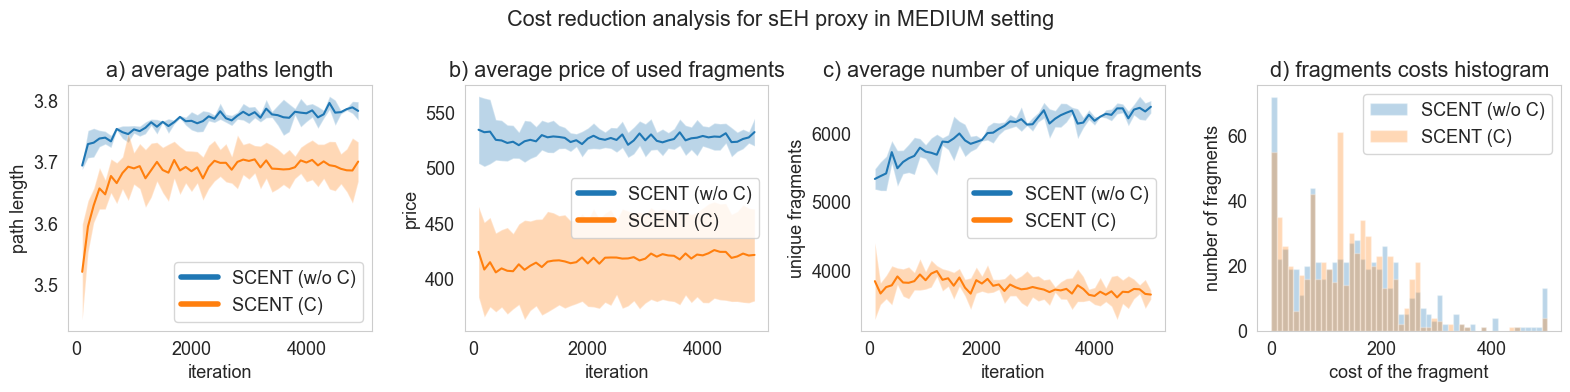

In [4]:
import json
from typing import Literal
import matplotlib.pyplot as plt

def plot_revisits_scaffolds(results: TrainingResultsList, reward_threshold: float, max_or_std='max', n: int = 64, mean: bool = False, start_at: int = 0, end_at: int = None):
    results = results.results
    model_name = model_map[results[0].model_name]

    y_list_list = []
    for result in results:
        y_list = []
        scaffold_counter = {}
        for i, (scaffold, reward) in enumerate(zip(result.scaffolds, result.rewards)):
            if scaffold in scaffold_counter:
                scaffold_counter[scaffold] += 1
            elif reward >= reward_threshold:
                scaffold_counter[scaffold] = 0
            if i % n == 0:
                sum_counts = sum(scaffold_counter.values())
                if mean:
                    y_list.append(sum_counts / max(len(scaffold_counter), 1))
                else:
                    y_list.append(sum_counts)
        y_list_list.append(y_list)

    if end_at is None:
        end_at = len(y_list_list[0])
    x = np.array(range(len(y_list_list[0])))[start_at:end_at]
    y = np.array(y_list_list)[:, start_at:end_at]
    y_mean = np.mean(y, axis=0)
    plt.plot(x, y_mean, label=model_name)

    if max_or_std == 'std':
        y_std = np.std(y, axis=0)
        _floor = y_mean - y_std
        _floor[_floor < 0] = 0
        plt.fill_between(x, _floor, y_mean + y_std, alpha=0.3)
    else:
        y_min = np.min(y, axis=0)
        y_max = np.max(y, axis=0)
        plt.fill_between(x, y_min, y_max, alpha=0.3)

def plot_cost_histogram(results: TrainingResultsList, n: int = 1000, max_value: float = 1000.0):
    last_n_fragments = []
    single_results: TrainingResults = results.results[0]
    for fragment_list in single_results.fragments_list_list[-n:]:
        for fragment in fragment_list:
            last_n_fragments.append(fragment)
        if len(last_n_fragments) >= n:
            break
    fragments_costs = np.array([path_cost_proxy.get_fragment_smiles_cost(fragment) for fragment in last_n_fragments])
    plt.hist(np.clip(fragments_costs, a_min=0, a_max=max_value), 
             label=model_map[single_results.model_name], 
             alpha=0.3,
             bins=np.arange(0, max_value + 10, 10))  #bins=np.logspace(np.log10(5),np.log10(1000.0), 100))
    return fragments_costs

plot_dict = defaultdict(dict)
def plot_metric(results: TrainingResultsList, metric: str, max_or_std: Literal['max', 'std'] = 'std'):
    results = results.results
    # max_len_results_idx = np.argmax([len(result.__getattribute__(metric)) for result in results])
    x = list(range(len(results[0].__getattribute__(metric)[::64])))[100:][::100]
    y = [result.__getattribute__(metric)[::64][100:][::100] for result in results]

    y_mean = np.mean(y, axis=0)
    y_std = np.std(y, axis=0)
    plt.plot(x, y_mean, label=model_map[results[0].model_name])
    
    plot_dict[model_map[results[0].model_name]][metrics_map[metric]] = {'mean': list(y_mean), 'std': list(y_std)}

    if max_or_std == 'std':
        y_std = np.std(y, axis=0)
        _floor = y_mean - y_std
        _floor[_floor < 0] = 0
        plt.fill_between(x, _floor, y_mean + y_std, alpha=0.3)
    else:
        y_min = np.min(y, axis=0)
        y_max = np.max(y, axis=0)
        plt.fill_between(x, y_min, y_max, alpha=0.3)

import matplotlib
matplotlib.rcParams.update({'font.size': 13})
if template_name == 'synflow_64':
    metrics = ['last_n_paths_lengths', 'last_n_price_of_fragments_in_path', 'last_n_unique_fragments']
else:
    metrics= ['last_n_paths_lengths', 'last_n_price_of_fragments_in_path', 'last_n_unique_fragments', 'last_n_reaction_yield']
total_subplots = 4
plt.figure(figsize=(4 * total_subplots, 4))
plt.suptitle(f'Cost reduction analysis for sEH proxy in {template_map[template_name]} setting')
for model_name, results_list in results_dict.items():
    for i, metric in enumerate(metrics, 1):
        plt.subplot(1, total_subplots, i)
        plt.title(metrics_map[metric])
        for results in results_list:
            plot_metric(results, metric, 'std')
            plt.grid(False)
        plt.xlabel('iteration')
        plt.ylabel(y_axis_map[metric])
        leg = plt.legend()
        for line in leg.get_lines():
            line.set_linewidth(4.0)

if template_name == 'synflow_64':
    n = 640
    plt.subplot(1, total_subplots, total_subplots)
    plt.title(f'd) fragments costs histogram')
    for model_name, results_list in results_dict.items():
        for results in results_list:
            costs = plot_cost_histogram(results, n=n, max_value=500.0)
            plot_dict[model_map[model_name]][f'd) fragments costs histogram'] = {'costs': list(costs)}
            plt.grid(False)
    plt.xlabel('cost of the fragment')
    plt.ylabel(f'number of fragments')
    leg = plt.legend()
    for line in leg.get_lines():
        line.set_linewidth(1.0)
        line.set_alpha(1.0)

json.dump(dict(plot_dict), open(f'plotting_data/figure_4_8_MEDIUM.json', 'w'), indent=4)
plt.tight_layout()
# plt.ylabel(f'number of fragments in the last {n} paths')
plt.savefig(f'outputs/cost_analysis_{template_name}.pdf', bbox_inches = 'tight')
plt.show()

In [ ]:
# n = 640
# 
# metrics = ['last_n_unique_fragments']
# total_subplots = len(metrics) + 2
# plt.figure(figsize=(5 * total_subplots, 3.5))
# 
# plt.subplot(1, total_subplots, 1)
# reward = 7.0
# for model_name, results_list in results_dict.items():
#     for results in results_list:
#         plot_revisits_scaffolds(results, reward_threshold=reward, max_or_std='std', mean=True, start_at=200, end_at=None)
# plt.title(f'High reward scaffolds')
# plt.xlabel('iteration')
# plt.ylabel(f'revisits of scaffolds with high-reward')
# plt.legend()
# 
# plt.suptitle(f'Exploitation analysis in {template_map[template_name]} setting')
# for model_name, results_list in results_dict.items():
#     for i, metric in enumerate(metrics, 1):
#         plt.subplot(1, total_subplots, i + 1)
#         plt.title(metrics_map[metric])
#         for results in results_list:
#             plot_metric(results, metric, 'std')
#         plt.xlabel('iteration')
#         plt.ylabel(f'number of fragments in the last {n} paths')
#         plt.legend()
# 
# 
# plt.subplot(1, total_subplots, total_subplots)
# plt.title(f'Fragments costs histogram')
# for model_name, results_list in results_dict.items():
#     for results in results_list:
#         plot_cost_histogram(results, n=n, max_value=500.0)
# plt.xlabel('cost of the fragment')
# plt.ylabel(f'number of fragments in the last {n} paths')
# plt.tight_layout()
# plt.legend()
# plt.savefig(f'outputs/exploitation_analysis_{template_name}.pdf')
# plt.show()